In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from google.colab import files
from nltk.stem import SnowballStemmer
from wordcloud import WordCloud
from sklearn.utils import resample
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

In [2]:
from google.colab import files
import os

# Upload kaggle.json when prompted
files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d datafiniti/consumer-reviews-of-amazon-products
!unzip -q consumer-reviews-of-amazon-products.zip -d data/
!ls data/

Saving Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv to Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/datafiniti/consumer-reviews-of-amazon-products
License(s): CC-BY-NC-SA-4.0
100% 16.3M/16.3M [00:00<00:00, 172MB/s]

1429_1.csv
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv


### 1. Data Preprocessing for Product Segmentation
In this step, we aggregate the raw review data into a unique product-level dataset. We calculate the **average rating** and **recommendation rate** for each product while preserving its **name** and **category**.
This is crucial for K-means, as it ensures we cluster products, not individual review entries.

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

# Load the dataset
df_original = pd.read_csv("data/1429_1.csv")

# 1. Aggregate data to a product level
# We group by 'name' to ensure each product is represented only once
product_df = df_original.groupby('name').agg({
    'categories': 'first',
    'reviews.rating': 'mean',
    'reviews.doRecommend': lambda x: x.map({True: 1, False: 0}).mean()
}).reset_index()

# Handle missing values in the recommendation rate (fill with 0)
product_df['reviews.doRecommend'] = product_df['reviews.doRecommend'].fillna(0)

# 2. Scale the numerical features
# Scaling is essential for K-means to prevent features with larger ranges from dominating
scaler = StandardScaler()
scaled_numeric = scaler.fit_transform(product_df[['reviews.rating', 'reviews.doRecommend']])

print(f"Product-level dataset created with {product_df.shape[0]} unique products.")

Product-level dataset created with 48 unique products.


/tmp/ipykernel_4102/2825647754.py:8: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original = pd.read_csv("data/1429_1.csv")


### 2. Exploratory Data Analysis (EDA)
Before clustering, we visualize the distribution of our numerical features: **Average Rating** and **Recommendation Rate**. This helps us understand the quality and popularity of products across the dataset.

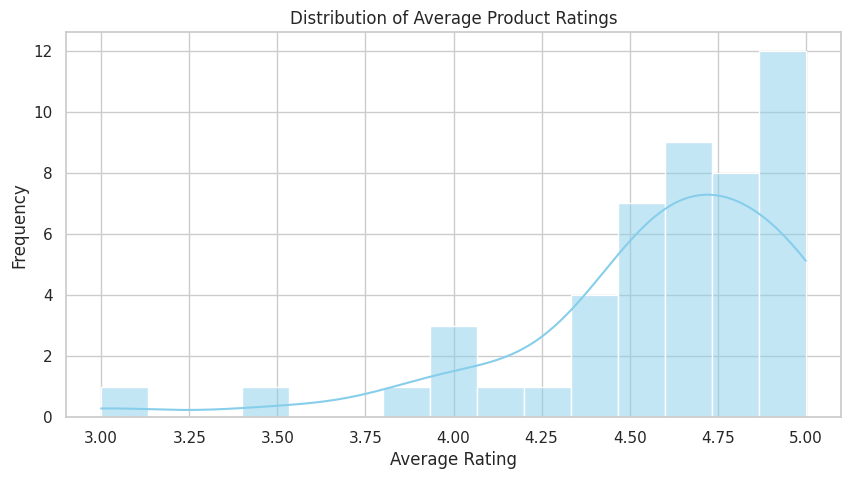

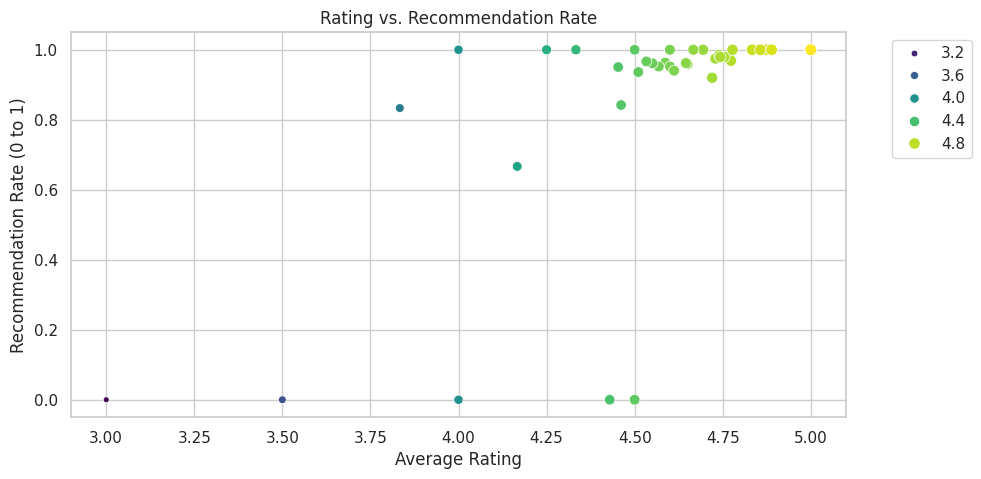

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid")

# 1. Distribution of Average Ratings
plt.figure(figsize=(10, 5))
sns.histplot(product_df['reviews.rating'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of Average Product Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Frequency')
plt.show()

# 2. Relationship between Rating and Recommendation Rate
plt.figure(figsize=(10, 5))
sns.scatterplot(data=product_df, x='reviews.rating', y='reviews.doRecommend', size='reviews.rating', hue='reviews.rating', palette='viridis')
plt.title('Rating vs. Recommendation Rate')
plt.xlabel('Average Rating')
plt.ylabel('Recommendation Rate (0 to 1)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

### 3. Generating Semantic Embeddings
We convert the product metadata (**Name** and **Category**) into high-dimensional vectors using the **Sentence-BERT** model. These embeddings capture the semantic meaning of each product.

In [5]:
from sentence_transformers import SentenceTransformer

# Prepare combined text
product_df['text_for_embedding'] = product_df['name'] + " [CATEGORY] " + product_df['categories']

# Generate Embeddings
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
text_embeddings = embedding_model.encode(product_df['text_for_embedding'].tolist(), show_progress_bar=True)

# Combine scaled numerical data with text embeddings
# (Using 'scaled_numeric' from Step 1)
X_combined = np.hstack((scaled_numeric, text_embeddings))

print(f"Combined Feature Matrix Shape: {X_combined.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Combined Feature Matrix Shape: (48, 386)


### 4. Elbow Method for Optimal K
To find the most natural number of clusters, we use the **Elbow Method**. We calculate the **Within-Cluster Sum of Squares (WCSS)** for a range of clusters (1 to 10). The 'elbow' point indicates where adding more clusters provides diminishing returns.

Clusters (k)    | WCSS (Inertia)      
----------------------------------------
1               | 113.67              
2               | 49.75               
3               | 35.22               
4               | 26.94               
5               | 20.70               
6               | 18.52               
7               | 17.12               
8               | 16.15               
9               | 14.67               
10              | 13.91               


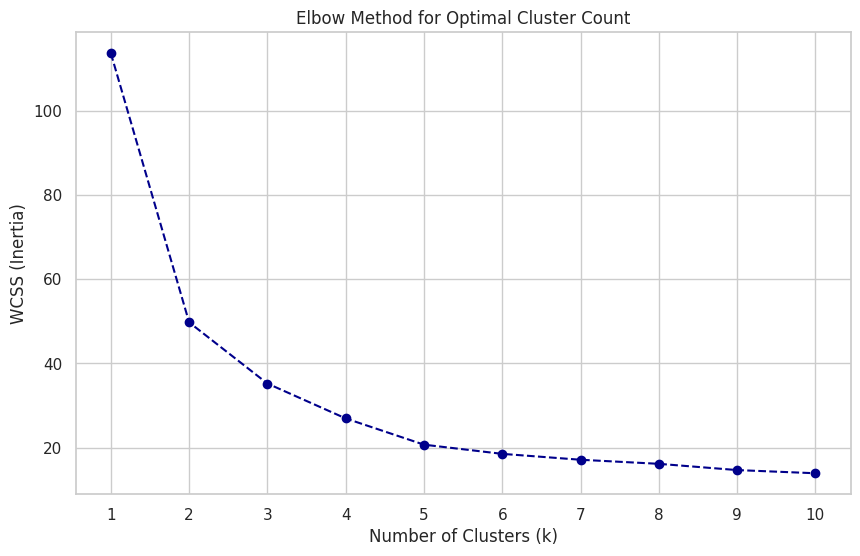

In [6]:
from sklearn.cluster import KMeans

wcss = []
K_range = range(1, 11)

print(f"{'Clusters (k)':<15} | {'WCSS (Inertia)':<20}")
print("-" * 40)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_combined)
    inertia = kmeans.inertia_
    wcss.append(inertia)

    # Spausdiname kiekvieno žingsnio rezultatą
    print(f"{k:<15} | {inertia:<20.2f}")

# Plotting the Elbow Graph
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='darkblue')
plt.title('Elbow Method for Optimal Cluster Count')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

### 5. Applying K-Means with Optimal K (k=5)
Following the project requirements (4-6 categories) and the mathematical evidence from the Elbow method, we select **k=5**. This allows for a granular yet interpretable segmentation of Amazon products.

In [7]:
# Set the optimal number of clusters based on business requirements and Elbow method
optimal_k = 5

# Initialize and fit the model
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
product_df['cluster'] = kmeans.fit_predict(X_combined)

# Sort by cluster to see the groupings clearly
result_df = product_df[['name', 'cluster', 'reviews.rating', 'categories']].sort_values(by='cluster')

# Save or display the results
print(f"Products successfully grouped into {optimal_k} clusters.")
display(result_df.head(20))

# Quick check on cluster sizes
print("\nNumber of products per cluster:")
print(product_df['cluster'].value_counts().sort_index())

Products successfully grouped into 5 clusters.


,name,cluster,reviews.rating,categories
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",0,4.586709,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",0,4.568493,"Kindle Store,Amazon Devices,Electronics"
5,Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Bl...,0,4.720000,"Fire Tablets,Tablets,Computers & Tablets,All T..."
4,"Amazon - Fire 16GB (5th Gen, 2015 Release) - B...",0,4.600000,"Walmart for Business,Office Electronics,Tablet..."
7,Amazon 5W USB Official OEM Charger and Power A...,0,4.461538,"Tablets,Fire Tablets,Computers & Tablets,All T..."
15,"Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",0,4.650178,"Stereos,Remote Controls,Amazon Echo,Audio Dock..."
13,Amazon Fire Hd 8 8in Tablet 16gb Black B018szt...,0,4.740741,"Walmart for Business,Office Electronics,Tablet..."
8,Amazon 9W PowerFast Official OEM USB Charger a...,0,4.694444,"Stereos,Remote Controls,Amazon Echo,Audio Dock..."
21,Amazon Kindle Paperwhite - eBook reader - 4 GB...,0,4.755038,"Tablets,Fire Tablets,Computers & Tablets,All T..."
24,Brand New Amazon Kindle Fire 16gb 7 Ips Displa...,0,4.550823,"Fire Tablets,Tablets,Computers & Tablets,All T..."



Number of products per cluster:
cluster
0    19
1     2
2     6
3    18
4     3
Name: count, dtype: int64


### 6. Cluster Visualization using PCA
Since our feature matrix (X_combined) has many dimensions, we use **PCA** to reduce them to 2D. This allows us to visualize how the products are grouped and identify any overlaps or outliers (like Cluster 1 with low ratings).

) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


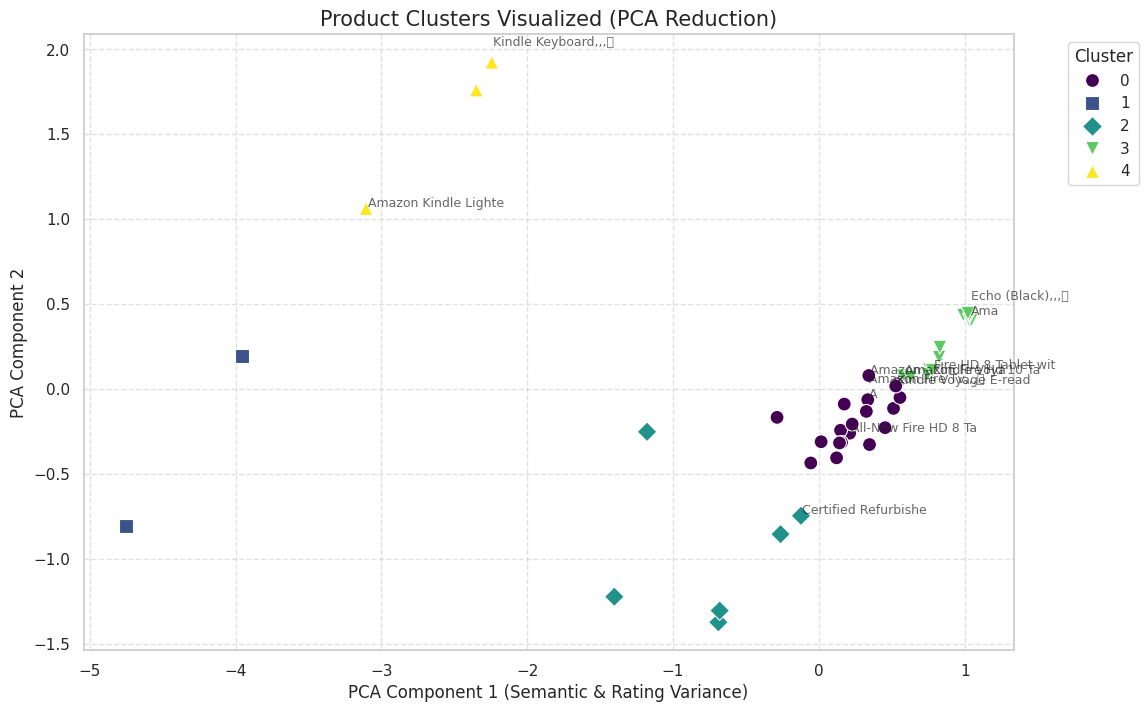

In [8]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Reduce dimensions to 2D for plotting
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_combined)

# 2. Add PCA results to our dataframe
product_df['pca_1'] = pca_features[:, 0]
product_df['pca_2'] = pca_features[:, 1]

# 3. Create the plot
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=product_df,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    palette='viridis',
    s=100,
    style='cluster',
    markers=['o', 's', 'D', 'v', '^']
)

# Add labels for some products to see what's happening
# (We only label a few to avoid clutter)
for i in range(0, len(product_df), 5):
    plt.text(
        product_df.pca_1[i]+0.01,
        product_df.pca_2[i]+0.01,
        product_df.name[i][:20],
        fontsize=9,
        alpha=0.7
    )

plt.title('Product Clusters Visualized (PCA Reduction)', fontsize=15)
plt.xlabel('PCA Component 1 (Semantic & Rating Variance)')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 7. Mapping Business Names to Clusters
Based on the previous analysis of ratings and product types within each group, we assign human-readable names to the clusters. This step transforms numerical labels (0-4) into meaningful business segments for the final application.

In [10]:
# 1. Map cluster numbers to names
cluster_names = {
    0: "Mainstream Core Devices",
    1: "Underperforming Outliers",
    2: "Budget & Refurbished Essentials",
    3: "Top-Rated & Premium Picks",
    4: "Legacy & Niche Gadgets"
}

product_df['cluster_name'] = product_df['cluster'].map(cluster_names)

# 2. Select columns including 'cluster' so we can sort by it
# We keep 'cluster' for sorting, then we can display the rest
final_summary = product_df[['name', 'cluster', 'cluster_name', 'reviews.rating', 'categories']]
final_summary = final_summary.sort_values(by='cluster')

# 3. Display the results
print("Final Categorization Sample:")
display(final_summary[['name', 'cluster_name', 'reviews.rating']].head(10))

Final Categorization Sample:


,name,cluster_name,reviews.rating
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Mainstream Core Devices,4.586709
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Mainstream Core Devices,4.568493
5,Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Bl...,Mainstream Core Devices,4.720000
4,"Amazon - Fire 16GB (5th Gen, 2015 Release) - B...",Mainstream Core Devices,4.600000
7,Amazon 5W USB Official OEM Charger and Power A...,Mainstream Core Devices,4.461538
15,"Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",Mainstream Core Devices,4.650178
13,Amazon Fire Hd 8 8in Tablet 16gb Black B018szt...,Mainstream Core Devices,4.740741
8,Amazon 9W PowerFast Official OEM USB Charger a...,Mainstream Core Devices,4.694444
21,Amazon Kindle Paperwhite - eBook reader - 4 GB...,Mainstream Core Devices,4.755038
24,Brand New Amazon Kindle Fire 16gb 7 Ips Displa...,Mainstream Core Devices,4.550823


### 8. Detailed Cluster Content Analysis
To give meaningful names to our clusters, we need to inspect exactly which products were grouped together. This script iterates through each cluster, counts the products, and lists their names alongside their average ratings.

In [11]:
# 8. Detailed Analysis with Business Names
for i in range(optimal_k):
    print(f"\n" + "="*75)

    # Filter products and get the business name
    cluster_group = product_df[product_df['cluster'] == i]
    # Take the first name found for this cluster
    business_name = cluster_names[i]

    product_count = len(cluster_group)
    avg_rating = cluster_group['reviews.rating'].mean()

    print(f"CLUSTER {i}: {business_name}")
    print(f"Total Products: {product_count} | Average Rating: {avg_rating:.2f}")
    print("-" * 75)

    # List products with their specific ratings
    for index, row in cluster_group.iterrows():
        name_snippet = row['name'][:65]
        print(f"• {name_snippet:<65} | Rating: {row['reviews.rating']:.2f}")


CLUSTER 0: Mainstream Core Devices
Total Products: 19 | Average Rating: 4.61
---------------------------------------------------------------------------
• All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes S | Rating: 4.59
• All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes S | Rating: 4.57
• Amazon - Fire 16GB (5th Gen, 2015 Release) - Black,,,
Amazon - F | Rating: 4.60
• Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Black,,,
Amazon - Ki | Rating: 4.72
• Amazon 5W USB Official OEM Charger and Power Adapter for Fire Tab | Rating: 4.46
• Amazon 9W PowerFast Official OEM USB Charger and Power Adapter fo | Rating: 4.69
• Amazon Fire Hd 8 8in Tablet 16gb Black B018szt3bk 6th Gen (2016)  | Rating: 4.74
• Amazon Fire Tv,,,
Amazon Fire Tv,,,                              | Rating: 4.65
• Amazon Kindle Fire Hd (3rd Generation) 8gb,,,
Amazon Kindle Fire | Rating: 4.50
• Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Pap | Rating: 4.76
• Brand New Amazon K

### 9. Cluster Performance Summary
This summary table provides a high-level business overview of each segment. It calculates the average rating, counts the inventory, and identifies the "star product" (Top Product) for each cluster, making it easy to present the results to stakeholders.

In [12]:
# Create a summary of each cluster
cluster_summary = []

for i in range(optimal_k):
    cluster_data = product_df[product_df['cluster'] == i]

    # Identify the top-rated product in this cluster
    top_product = cluster_data.sort_values(by='reviews.rating', ascending=False).iloc[0]['name']

    cluster_summary.append({
        'Segment Name': cluster_names[i],
        'Total Products': len(cluster_data),
        'Average Rating': round(cluster_data['reviews.rating'].mean(), 2),
        'Top Rated Product': top_product[:50] + "..." # Shortened for the table
    })

# Convert to DataFrame
summary_df = pd.DataFrame(cluster_summary)

# Display the final summary table
print("Business Executive Summary:")
display(summary_df)

Business Executive Summary:


,Segment Name,Total Products,Average Rating,Top Rated Product
0,Mainstream Core Devices,19,4.61,Amazon Kindle Paperwhite - eBook reader - 4 GB...
1,Underperforming Outliers,2,3.25,"Amazon Kindle Lighted Leather Cover,,,\r\nAmaz..."
2,Budget & Refurbished Essentials,6,4.10,Certified Refurbished Amazon Fire TV (Previous...
3,Top-Rated & Premium Picks,18,4.92,Certified Refurbished Amazon Fire TV Stick (Pr...
4,Legacy & Niche Gadgets,3,4.31,"Kindle Keyboard,,,\r\nKindle Keyboard,,,..."


In [13]:
import plotly.express as px

# 1. Prepare data summary
treemap_data = product_df.groupby(['cluster_name']).agg({
    'name': 'count',
    'reviews.rating': 'mean'
}).reset_index()

treemap_data.columns = ['Category', 'Product Count', 'Average Rating']

# 2. Create the Treemap with Purple-Pink-Yellow scale
# We use 'Plasma' scale which naturally transitions from Purple to Pink to Yellow
fig_tree = px.treemap(
    treemap_data,
    path=['Category'],
    values='Product Count',
    color='Average Rating',
    color_continuous_scale='Plasma', # Professional Purple-Pink-Yellow transition
    title="Amazon Product Portfolio Map (Size = Inventory, Color = Satisfaction)"
)

# Optional: If you want to define your OWN specific colors:
# color_continuous_scale=['#4B0082', '#FF69B4', '#FFFF00'] # Indigo, HotPink, Yellow

fig_tree.update_layout(
    margin=dict(t=50, l=10, r=10, b=10),
    font=dict(family="Arial", size=14)
)

fig_tree.show()

## Data Export for Integration
This section bundles the clustered product data into a ZIP file for the next phase of analysis.

In [14]:
import zipfile
import os
from google.colab import files

# Define the filename based on your final dataframe
# Ensure 'product_df' or 'df' matches your variable name
output_file = 'clustered_results.csv'
zip_name = 'nlp_project_data.zip'

try:
    # Save to CSV first
    product_df.to_csv(output_file, index=False)

    # Create ZIP archive
    with zipfile.ZipFile(zip_name, 'w') as zipf:
        zipf.write(output_file)

    print(f"Successfully created {zip_name}")

    # Trigger download to local machine
    files.download(zip_name)

except NameError:
    print("Error: 'product_df' not found. Please check your variable name.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully created nlp_project_data.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>